<a href="https://colab.research.google.com/github/krackofficer/EDA-Assignment-in-Machine-Learning-/blob/main/Spotify_EDA4_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:


# Upload CSV manually
from google.colab import files
uploaded = files.upload()

Saving spotify.csv to spotify.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load and clean dataset
df = pd.read_csv("spotify.csv")
df.drop_duplicates(inplace=True)
print(df.shape)
df.head()

(413, 5)


,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe


## Q1: Null and duplicate check

In [5]:
print("Null values:")
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Null values:
Artist           0
Track Name       0
Popularity       0
Duration (ms)    0
Track ID         0
dtype: int64
Duplicate rows: 0


## Q2: Distribution of popularity

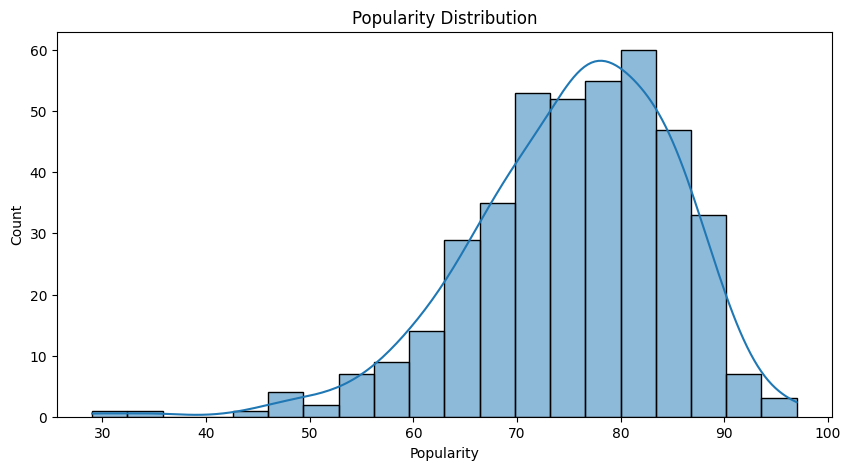

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['Popularity'], bins=20, kde=True)
plt.title("Popularity Distribution")
plt.show()

## Q3: Popularity vs Duration

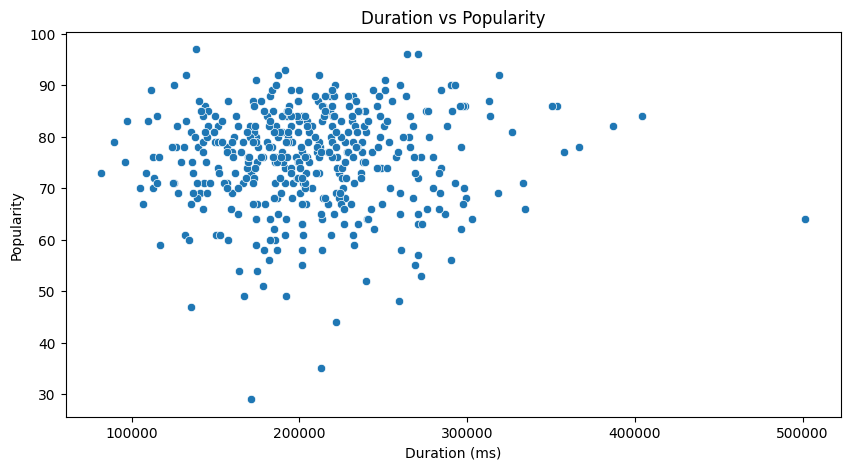

In [7]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='Duration (ms)', y='Popularity')
plt.title("Duration vs Popularity")
plt.show()

## Q4: Artist with most tracks

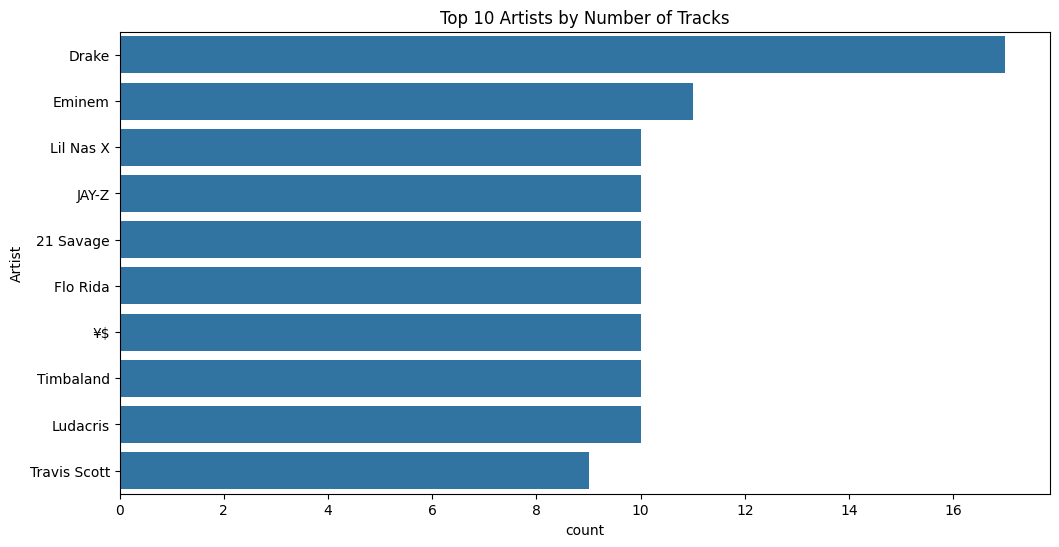

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(y='Artist', data=df, order=df['Artist'].value_counts().iloc[:10].index)
plt.title("Top 10 Artists by Number of Tracks")
plt.show()

## Q5: Least popular 5 tracks

In [9]:
df.nsmallest(5, 'Popularity')[['Artist', 'Track Name', 'Popularity']]

,Artist,Track Name,Popularity
207,Pressa,Attachments (feat. Coi Leray),29
231,Justin Bieber,Intentions,35
413,French Montana,Splash Brothers,44
225,Lil Baby,On Me - Remix,47
407,Wyclef Jean,911 (feat. Mary J. Blige),48


## Q6: Avg popularity of top 5 artists

In [10]:
top_artists = df['Artist'].value_counts().nlargest(5).index
df[df['Artist'].isin(top_artists)].groupby('Artist')['Popularity'].mean().sort_values(ascending=False)

,Popularity
Artist,
21 Savage,83.800000
Eminem,83.636364
Drake,82.882353
JAY-Z,77.900000
Lil Nas X,75.900000


## Q7: Most popular track for top artists

In [11]:
for artist in top_artists:
    top_track = df[df['Artist'] == artist].sort_values('Popularity', ascending=False).iloc[0]
    print(f"{artist}: {top_track['Track Name']} (Popularity: {top_track['Popularity']})")

Drake: Rich Baby Daddy (feat. Sexyy Red & SZA) (Popularity: 92)
Eminem: Without Me (Popularity: 90)
Lil Nas X: THATS WHAT I WANT (Popularity: 81)
JAY-Z: Ni**as In Paris (Popularity: 86)
21 Savage: redrum (Popularity: 96)


## Q8: Pairplot of numerical variables

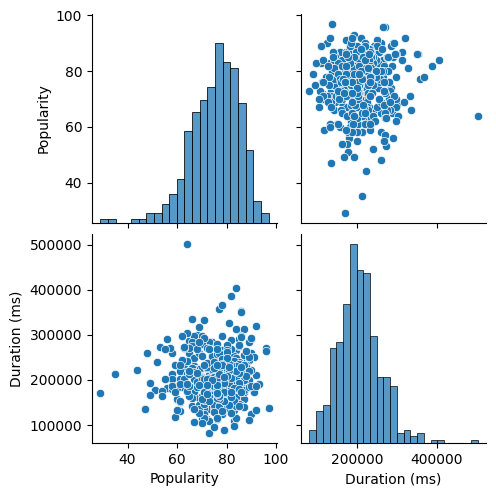

In [12]:
sns.pairplot(df[['Popularity', 'Duration (ms)']])
plt.show()

## Q9: Duration variation across artists

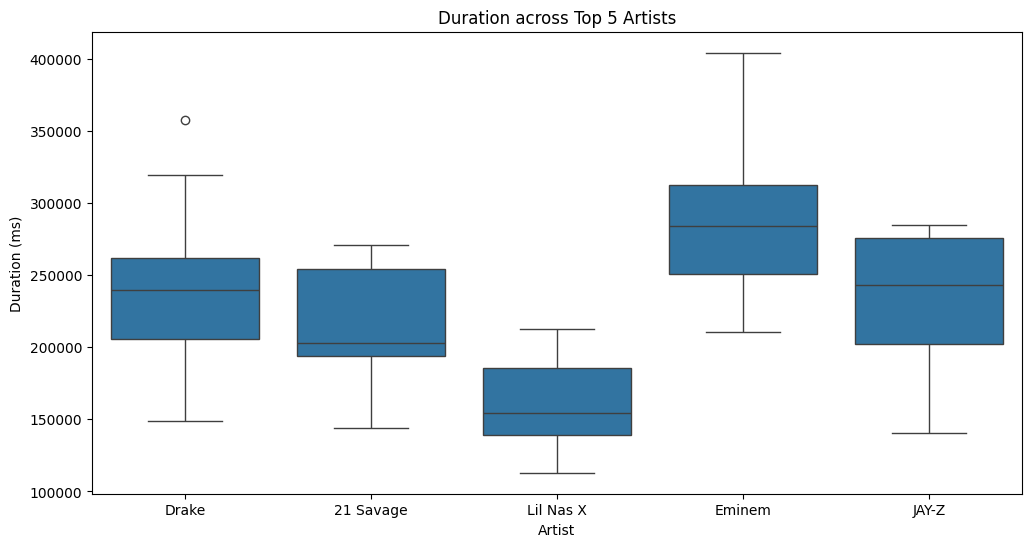

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['Artist'].isin(top_artists)], x='Artist', y='Duration (ms)')
plt.title("Duration across Top 5 Artists")
plt.show()

## Q10: Popularity distribution by artist

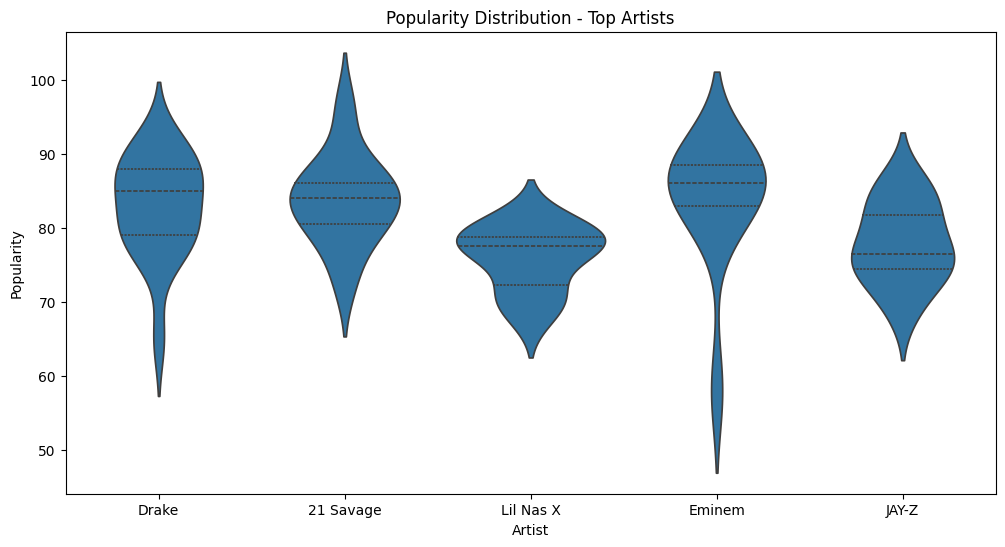

In [14]:
plt.figure(figsize=(12,6))
sns.violinplot(data=df[df['Artist'].isin(top_artists)], x='Artist', y='Popularity', inner='quartile')
plt.title("Popularity Distribution - Top Artists")
plt.show()